# Chapter 2 — Activation Functions

**The building block this notebook untangles:** Chapter 1's neuron used `step` —
fire or don't. That's fine for hand-picked weights, but it's *unusable* for
learning: the step function is flat almost everywhere, so it has a derivative of
either `0` or `undefined`. Gradient descent (Chapter 6) needs a *slope* to know
which way to adjust the weights. No slope, no learning signal.

Activation functions solve two problems at once:

1. They give a **smooth, non-zero gradient** almost everywhere, so a network can
   be nudged toward better weights.
2. They introduce **nonlinearity** — without it, stacking layers is pointless
   (we'll prove that below).

## Part 1 — Stacked linear layers are still linear

Before meeting the real activations, see *why* we need one at all. If every layer
just did `z = xW + b` with no activation in between, stacking two layers would
collapse into a single linear layer — no matter how many you stack.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

rng = np.random.default_rng(0)
x = rng.normal(size=(5, 3))          # 5 samples, 3 features
W1, b1 = rng.normal(size=(3, 4)), rng.normal(size=4)
W2, b2 = rng.normal(size=(4, 2)), rng.normal(size=2)

# Two "linear layers" stacked, no activation:
out_two_layers = (x @ W1 + b1) @ W2 + b2

# The equivalent single linear layer (same math, algebraically collapsed):
W_equiv = W1 @ W2
b_equiv = b1 @ W2 + b2
out_one_layer = x @ W_equiv + b_equiv

print("Two 'linear layers' output:\n", out_two_layers)
print("\nEquivalent single layer output:\n", out_one_layer)
print("\nIdentical?", np.allclose(out_two_layers, out_one_layer))

Two 'linear layers' output:
 [[ 1.92060329 -2.19130547]
 [ 1.66035957 -1.41199714]
 [ 1.1332682  -2.62289728]
 [ 1.88156173 -1.83418695]
 [ 1.62037281 -2.39379644]]

Equivalent single layer output:
 [[ 1.92060329 -2.19130547]
 [ 1.66035957 -1.41199714]
 [ 1.1332682  -2.62289728]
 [ 1.88156173 -1.83418695]
 [ 1.62037281 -2.39379644]]

Identical? True


Identical, to floating-point precision. Depth bought us *nothing* without a
nonlinearity between the layers. Every activation function below breaks this
collapse by bending the output in a way matrix multiplication alone can't undo.

## Part 2 — The four activations you'll actually use

- **Sigmoid** — squashes to `(0, 1)`. Reads naturally as a probability; classic
  choice for an output layer on a yes/no question.
- **Tanh** — squashes to `(-1, 1)`. Zero-centered, which often trains better than
  sigmoid in hidden layers.
- **ReLU** — `max(0, z)`. The default for hidden layers in modern networks: cheap,
  and doesn't saturate for positive inputs.
- **Softmax** — turns a vector of scores into a probability distribution that
  sums to 1; used on the output layer for multi-class classification.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_deriv(z):
    return 1 - np.tanh(z) ** 2

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def softmax(z):
    """z: (n_samples, n_classes). Subtract the max per row for numerical stability."""
    z_shifted = z - z.max(axis=-1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum(axis=-1, keepdims=True)

scores = np.array([2.0, 1.0, 0.1])
print("softmax([2.0, 1.0, 0.1]) =", softmax(scores), " sum =", softmax(scores).sum())

softmax([2.0, 1.0, 0.1]) = [0.65900114 0.24243297 0.09856589]  sum = 1.0


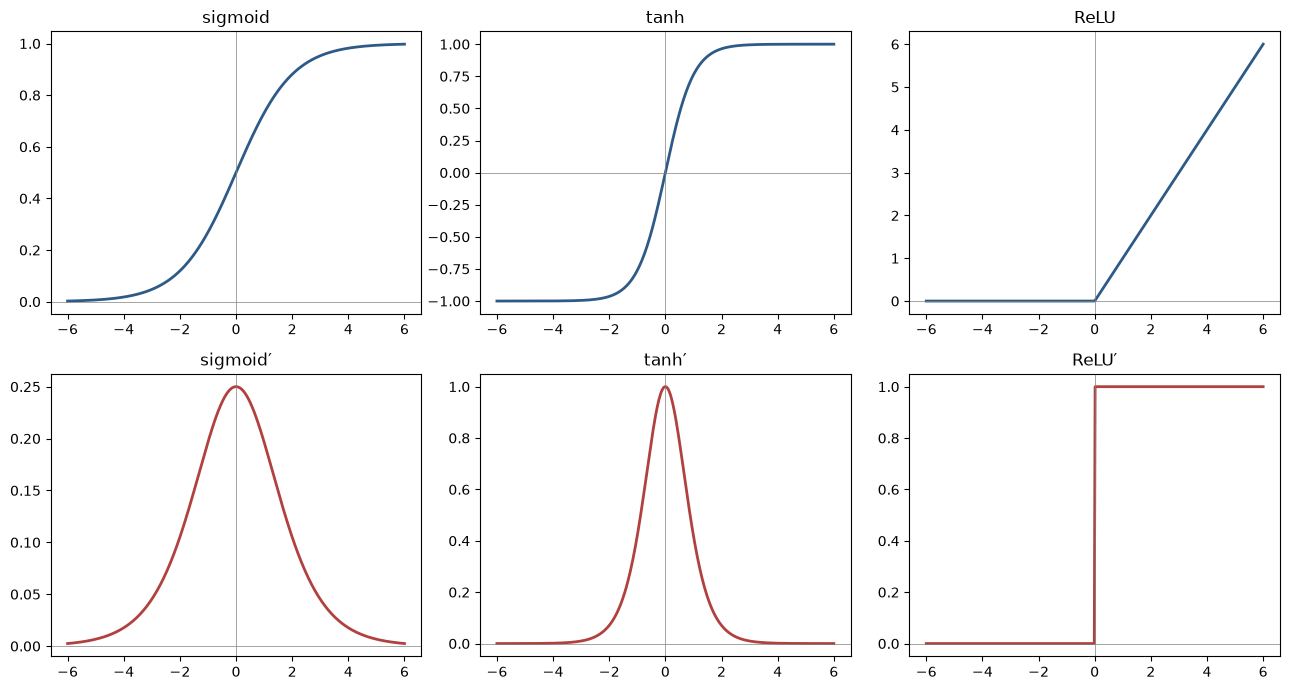

In [3]:
z = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, (name, fn) in zip(axes[0], [('sigmoid', sigmoid), ('tanh', tanh), ('ReLU', relu)]):
    ax.plot(z, fn(z), color='#2E5A88', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(name)

for ax, (name, deriv) in zip(axes[1], [('sigmoid′', sigmoid_deriv), ('tanh′', tanh_deriv), ('ReLU′', relu_deriv)]):
    ax.plot(z, deriv(z), color='#B0413E', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Part 3 — Why the derivative shape matters: saturation

Look at `sigmoid′`: it peaks at `0.25` and decays to nearly `0` once `|z| > 4`.
Once a sigmoid neuron's input is large in magnitude, its gradient is essentially
zero — the neuron is **saturated** and stops learning, no matter how wrong it is.
`ReLU′` never decays on the positive side, which is the main reason it became the
default for hidden layers.

In [4]:
z_extreme = np.array([-10, -4, 0, 4, 10], dtype=float)
print(f"{'z':>6} {'sigmoid(z)':>12} {'sigmoid grad':>13} {'relu grad':>10}")
for zi in z_extreme:
    print(f"{zi:>6.0f} {sigmoid(zi):>12.6f} {sigmoid_deriv(zi):>13.6f} {relu_deriv(zi):>10.0f}")

     z   sigmoid(z)  sigmoid grad  relu grad
   -10     0.000045      0.000045          0
    -4     0.017986      0.017663          0
     0     0.500000      0.250000          0
     4     0.982014      0.017663          1
    10     0.999955      0.000045          1


## Part 4 — Chapter 1's neuron, with a real activation

Swap `step` for `sigmoid` in the OR-gate neuron from Chapter 1. Instead of a hard
0/1, we now get a *confidence* — and, crucially, a gradient we can learn from.

In [5]:
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])
w, b = np.array([4.0, 4.0]), -2.0   # steeper weights so sigmoid outputs look decisive

print(f"{'x1':>3} {'x2':>3} {'z':>6} {'sigmoid(z)':>11} {'target':>7}")
for x, target in zip(X_or, y_or):
    z = np.dot(x, w) + b
    print(f"{x[0]:>3} {x[1]:>3} {z:>6.2f} {sigmoid(z):>11.4f} {target:>7}")

 x1  x2      z  sigmoid(z)  target
  0   0  -2.00      0.1192       0
  0   1   2.00      0.8808       1
  1   0   2.00      0.8808       1
  1   1   6.00      0.9975       1


## Recap

Activations turn a network from "a fixed line/plane" into something that can bend
around real data — and they give gradient descent a slope to follow. Sigmoid,
tanh, ReLU, and softmax each have a role; you'll use several of them in the same
network (e.g. ReLU in hidden layers, softmax on a multi-class output).

**Next:** [Chapter 3 — Layers & the Forward Pass](03_layers_and_forward_pass.ipynb)